My Octave Notebook 
============

Interact with Octave and the statistics-resampling package online in Jupyter Notebook with Binder. All commands are interpreted by Octave.  Since this is a [MetaKernel](https://github.com/Calysto/metakernel), a standard set of magics are available.  Help on commands is available using the `%help` magic or using `?` with a command. For the best experience, run this notebook in [Jupyter Lab](https://mybinder.org/v2/gh/acpennlab/statistics-resampling-online/master?labpath=statistics-resampling.ipynb). 

The code cells and their output below illustrate some examples of loading data and then performing analysis using functions from the **statistics-resampling** package. Follow the links in the **Quick start** section of the [README page](https://gnu-octave.github.io/statistics-resampling/readme.html), or on the [Function reference page](https://gnu-octave.github.io/statistics-resampling/function_reference), to find further examples. The example data files provided, **data1.tsv** and **data2.csv**, can be edited directly in this instance of JupyterLab. 

The statistics-resampling package already comes installed and loaded at **statistics-resampling-online**. Visit [GNU Octave Packages](https://gnu-octave.github.io/packages/) to see what other packages are available and how to install them. To load a newly installed package called `<package-name>`, use the command `pkg load <package-name>`. To preview demonstration number `X` of a function called `<function-name>`, use the command `demo ('<function-name>', X)`. To get more information about a particular function called `<function-name>`, use the command `help <function-name>`. Note that the **parallel** package cannot be installed at **statistics-resampling-online**, and that additions to the binder environment may be required to build or run some other Octave packages.

Some Octave packages come already installed and in this statistics-resampling-online Binder environment. If you were running Octave on your own machine, you would need to install and load the statistics-resampling package first by running the code in the following two cells:

In [1]:
format short g

In [2]:
# Run this command once to install the package
pkg install "https://github.com/gnu-octave/statistics-resampling/archive/refs/heads/master.zip"

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.6.1-dev
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [3]:
# Run this command in each new Octave session
pkg load statistics-resampling

Run the code in the next code cell if you wish to know:
1) The version of GNU Octave that you are running
2) What packages (and their version) are already installed (and loaded*) here
3) More information about the statistics-resampling package

In [4]:
ver('Octave');
pkg list;
pkg describe -verbose statistics-resampling

----------------------------------------------------------------------
GNU Octave Version: 8.3.0 (hg id: 6fc591af58ba)
GNU Octave License: GNU General Public License
Operating System: Linux 6.8.0-86-generic #87-Ubuntu SMP PREEMPT_DYNAMIC Mon Sep 22 18:03:36 UTC 2025 x86_64
----------------------------------------------------------------------
Package Name           | Version   | Installation directory
-----------------------+-----------+-----------------------
                coder  |     1.9.1 | .../octave/api-v58/packages/coder-1.9.1
              control  |     4.0.0 | .../octave/api-v58/packages/control-4.0.0
       data-smoothing  |     1.3.0 | .../api-v58/packages/data-smoothing-1.3.0
            dataframe  |     1.2.0 | .../api-v58/packages/dataframe-1.2.0
               fileio  |     1.2.2 | .../octave/api-v58/packages/fileio-1.2.2
                   ga  |    0.10.4 | .../octave/api-v58/packages/ga-0.10.4
                   io *|     2.6.4 | .../share/octave/api-v58/packages/io

In [5]:
# load genotype, condition and animal cluster
[~, genotype] = xlsread ('../data/basic_properties_data_coded.xlsx', 'OGS', 'E2:E77');
[~, condition] = xlsread ('../data/basic_properties_data_coded.xlsx', 'OGS', 'F2:F77');
animal = xlsread ('../data/basic_properties_data_coded.xlsx', 'OGS', 'B2:B77');

# fetch matrix of outcome measures
outcomes = xlsread ('../data/basic_properties_data_coded.xlsx', 'OGS', 'G2:R77');

# size of the data for each variable
disp(size(genotype))
disp(size(condition))
disp(size(animal))
disp(size(outcomes))


           76            1
           76            1
           76            1
           76           12


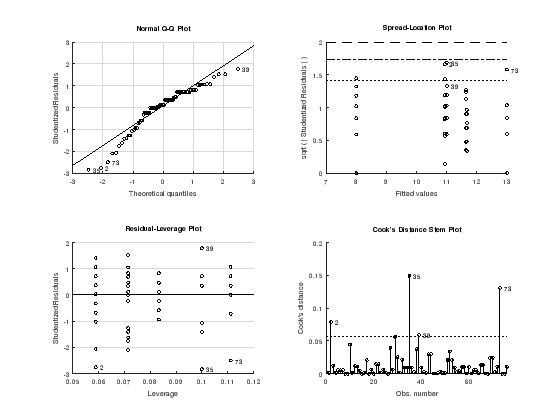

In [6]:
# making a loop so that the model is fitted through all 12 columns
for i = 1: size(outcomes, 2)
# model
    MAT_T = bootlm(outcomes(:,i), {genotype, condition}, 'model', 'full', 'display', 'on', ...
                   'contrasts', 'treatment', 'nboot', 0); 
    print(sprintf('../output/NCprac/outcome%d.png', i), '-dpng', '-r300')
end

In [ ]:
if (size (outcomes,1)) > 75
    genotype(6,:) = [];
    condition(6,:) = [];
    animal(6,:) = [];
    outcomes(6,:) = [];
    MAT_T.X(6,:) = [];
end

disp(size(genotype))
disp(size(condition))
disp(size(animal))
disp(size(outcomes))
disp(size(MAT_T.X))

    
    
    

           75            1
           75            1
           75            1
           75           12
           75            6


**Example 2** (below): Bootstrap two-way ANOVA (Type I) using `bootlm` with data (in long format) loaded from **data2.csv**.

ANOVA SUMMARY with effect of gender averaged over levels of degree
F(1,18) = 87.20, p = 0.0001 for the model: salary ~ 1 + degree
F(1,18) = 10.97, p = 0.00498 for the model: salary ~ 1 + degree + gender
F(1,18) = 0.42, p = 0.572 for the model: salary ~ 1 + degree + gender + degree:gender

MODEL FORMULA (based on Wilkinson's notation):

salary ~ 1 + degree + gender + degree:gender

MODEL COEFFICIENTS

name                                   coeff       CI_lower    CI_upper    p-val
--------------------------------------------------------------------------------
(Intercept)                            +20.00      +19.14      +20.92           
degree_1                               +7.000      +5.229      +8.822           
gender_1                               -3.000      -4.714      -1.094           
degree:gender_1                        +1.000      -1.623      +3.587           


MODEL FORMULA (based on Wilkinson's notation):

salary ~ 1 + degree + gender + degree:gender

MODEL ESTIMATE

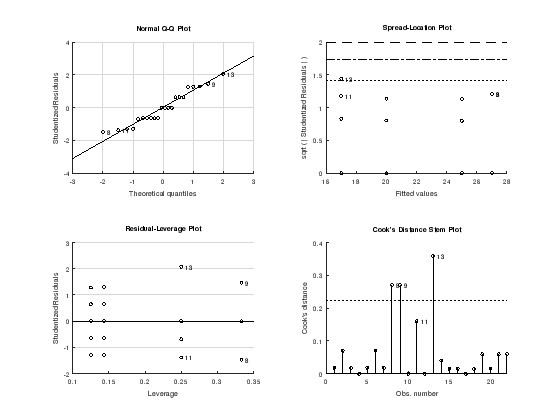

In [3]:
# Load data from comma-separated-value (CSV) file with header
# Formatting: each %d, %s and %f corresponds to an integer, a string and a
# number (double precision) respectively
[degree, gender, salary] = textread ('../data/data2.csv', '%d %s %f', 'Delimiter', ',', 'HeaderLines', 1);

# ANOVA using wild bootstrap
# https://gnu-octave.github.io/statistics-resampling/function/bootlm.html#7
[STATS, BOOTSTAT, AOVSTAT] = bootlm (salary, {degree, gender}, 'model', ...
                             'full', 'display', 'off', 'varnames', ...
                             {'degree', 'gender'}, 'seed', 1);

# Report ANOVA results
fprintf ('ANOVA SUMMARY with effect of gender averaged over levels of degree\n')
for i = 1:numel(AOVSTAT.MODEL)
  fprintf ('F(%u,%u) = %.2f, p = %.3g for the model: %s\n', ...
           AOVSTAT.DF(i), AOVSTAT.DFE, AOVSTAT.F(i), ...
           AOVSTAT.PVAL(i), AOVSTAT.MODEL{i});
end

# Calculate regression coefficients and 95% credible intervals (using bayesian bootstrap
# with an uninformative prior)
MDL = bootlm (salary, {degree, gender}, 'model', 'full', ...
                        'display', 'on', 'varnames', ...
                        {'degree', 'gender'}, 'method', 'bayesian', 'prior', 1);

# Calculate estimated marginal means and 95% credible intervals (using bayesian bootstrap
# with an uninformative prior)
EMMEANS = bootlm (salary, {degree, gender}, 'model', 'full', ...
                        'display', 'on', 'varnames', ...
                        {'degree', 'gender'}, 'dim', [1, 2], ...
                        'method', 'bayesian', 'prior', 'auto');

# Test whether salaries averaged over levels of college differ between men and 
# women (using wild bootstrap)
POSTTESTS = bootlm (salary, {degree, gender}, 'model', 'full', ...
                        'display', 'on', 'varnames', ...
                        {'degree', 'gender'}, 'dim', 2, ...
                        'posthoc', [1, 2]);

# Save the figure of the diagnostic plots
print ('../output/diagnostic_plots.svg','-dsvg')
#print ('../output/diagnostic_plots.png','-dpng','-r300')

**Example 3** (below): Bootstrap two-way ANOVA (Type I) using `bootlm` with data (in long format) as above but loaded from **data.xlsx**.

In [4]:
# Load data from Microsoft Excel or Open Office document spreadsheet
# First output is for numeric data, second output is for text data
# https://octave.sourceforge.io/io/function/xlsread.html
[degree, gender] = xlsread ('../data/data.xlsx', 'data2', 'A2:B23');
salary = xlsread ('../data/data.xlsx', 'data2', 'C2:C23');

# As above, ANOVA using wild bootstrap
[STATS, BOOTSTAT, AOVSTAT] = bootlm (salary, {degree, gender}, 'model', ...
                             'full', 'display', 'off', 'varnames', ...
                             {'degree', 'gender'}, 'seed', 1);

# Report ANOVA results
fprintf ('ANOVA SUMMARY with effect of gender averaged over levels of degree\n')
for i = 1:numel(AOVSTAT.MODEL)
  fprintf ('F(%u,%u) = %.2f, p = %.3g for the model: %s\n', ...
           AOVSTAT.DF(i), AOVSTAT.DFE, AOVSTAT.F(i), ...
           AOVSTAT.PVAL(i), AOVSTAT.MODEL{i});
end

ANOVA SUMMARY with effect of gender averaged over levels of degree
F(1,18) = 87.20, p = 0.0001 for the model: salary ~ 1 + degree
F(1,18) = 10.97, p = 0.00498 for the model: salary ~ 1 + degree + gender
F(1,18) = 0.42, p = 0.572 for the model: salary ~ 1 + degree + gender + degree:gender


In [3]:
help xlsread

'xlsread' is a function from the file /home/jovyan/.local/share/octave/api-v58/packages/io-2.6.4/xlsread.m

 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME)
 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME,
          WSH)
 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME,
          RANGE)
 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME,
          WSH, RANGE)
 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME,
          WSH, RANGE, INTERFACE, ...)
 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME,
          WSH, RANGE, OPTIONS, ...)
 -- Function File: [NUMARR, TXTARR, RAWARR, LIMITS] = xlsread (FILENAME,
          WSH, RANGE, VERBOSE, ...)
 -- Function File: [NUMARR, TXTARR, RAWARR, EXTOUT, LIMITS] = xlsread
          (FILENAME, WSH, RANGE, FUNC_HANDLE, ...)
     Read data from a spreadsheet file.

     Out of the box, xlsread can read data from .xlsx, 

In [4]:
help bootlm

'bootlm' is a function from the file /home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.6.1-dev/bootlm.m

 Uses bootstrap to calculate confidence intervals (and p-values) for the
 regression coefficients from a linear model and performs N-way ANOVA.

 -- Function File: bootlm (Y, X)
 -- Function File: bootlm (Y, GROUP)
 -- Function File: bootlm (Y, GROUP, ..., NAME, VALUE)
 -- Function File: bootlm (Y, GROUP, ..., 'dim', DIM)
 -- Function File: bootlm (Y, GROUP, ..., 'continuous', CONTINUOUS)
 -- Function File: bootlm (Y, GROUP, ..., 'model', MODELTYPE)
 -- Function File: bootlm (Y, GROUP, ..., 'standardize', STANDARDIZE)
 -- Function File: bootlm (Y, GROUP, ..., 'varnames', VARNAMES)
 -- Function File: bootlm (Y, GROUP, ..., 'method', METHOD)
 -- Function File: bootlm (Y, GROUP, ..., 'method', 'bayesian', 'prior', PRIOR)
 -- Function File: bootlm (Y, GROUP, ..., 'alpha', ALPHA)
 -- Function File: bootlm (Y, GROUP, ..., 'display', DISPOPT)
 -- Function File: boot